In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

search_time = pd.read_csv("search_time.csv")
collision_count = pd.read_csv("collisions.csv")

display(search_time.head())
display(collision_count.head())

print(search_time.shape)
print(collision_count.shape)

,run,size,algorithm,nanoseconds
0,0,100,linear_search,34806.0
1,0,100,binary_search_tree,672.0
2,0,100,red_black_tree,650.0
3,0,100,hash_table,736.0
4,0,100,multimap,814.0


,run,size,collisions
0,0,100,0
1,1,100,0
2,2,100,0
3,3,100,0
4,4,100,1


(425, 4)
(85, 3)


In [3]:
mean_search_time = (
    search_time
    .groupby(["size", "algorithm"], as_index=False)
    .agg(
        mean_nanoseconds=("nanoseconds", "mean"),
        std_nanoseconds=("nanoseconds", "std"),
        min_nanoseconds=("nanoseconds", "min"),
        max_nanoseconds=("nanoseconds", "max")
    )
)

mean_collision_count = (
    collision_count
    .groupby("size", as_index=False)
    .agg(
        mean_collisions=("collisions", "mean"),
        std_collisions=("collisions", "std"),
        min_collisions=("collisions", "min"),
        max_collisions=("collisions", "max")
    )
)

display(mean_search_time.head(20))
display(mean_collision_count.head(20))

,size,algorithm,mean_nanoseconds,std_nanoseconds,min_nanoseconds,max_nanoseconds
0,100,binary_search_tree,565.6,150.328973,452.0,778.0
1,100,hash_table,566.4,165.271897,432.0,758.0
2,100,linear_search,15207.2,10958.025972,10040.0,34806.0
3,100,multimap,702.0,137.513636,600.0,886.0
4,100,red_black_tree,534.8,159.277117,416.0,758.0
5,200,binary_search_tree,498.4,32.477685,448.0,528.0
6,200,hash_table,482.8,42.109381,410.0,514.0
7,200,linear_search,20090.0,393.057248,19526.0,20616.0
8,200,multimap,630.4,46.613303,578.0,706.0
9,200,red_black_tree,461.2,44.420716,410.0,526.0


,size,mean_collisions,std_collisions,min_collisions,max_collisions
0,100,0.2,0.447214,0,1
1,200,0.4,0.547723,0,1
2,500,3.0,1.870829,1,6
3,1000,12.2,2.049390,10,14
4,2000,47.0,5.385165,39,54
5,5000,213.2,9.884331,202,225
6,10000,546.0,14.142136,524,560
7,20000,1080.8,12.316655,1061,1092
8,30000,1360.6,12.095454,1344,1375
9,40000,1484.2,14.686729,1473,1507


In [4]:
algorithm_names = {
    "linear_search": "Линейный поиск",
    "binary_search_tree": "Бинарное дерево поиска",
    "red_black_tree": "Красно-чёрное дерево",
    "hash_table": "Хэш-таблица",
    "multimap": "std::multimap"
}

mean_search_time["algorithm_name"] = mean_search_time["algorithm"].map(algorithm_names)

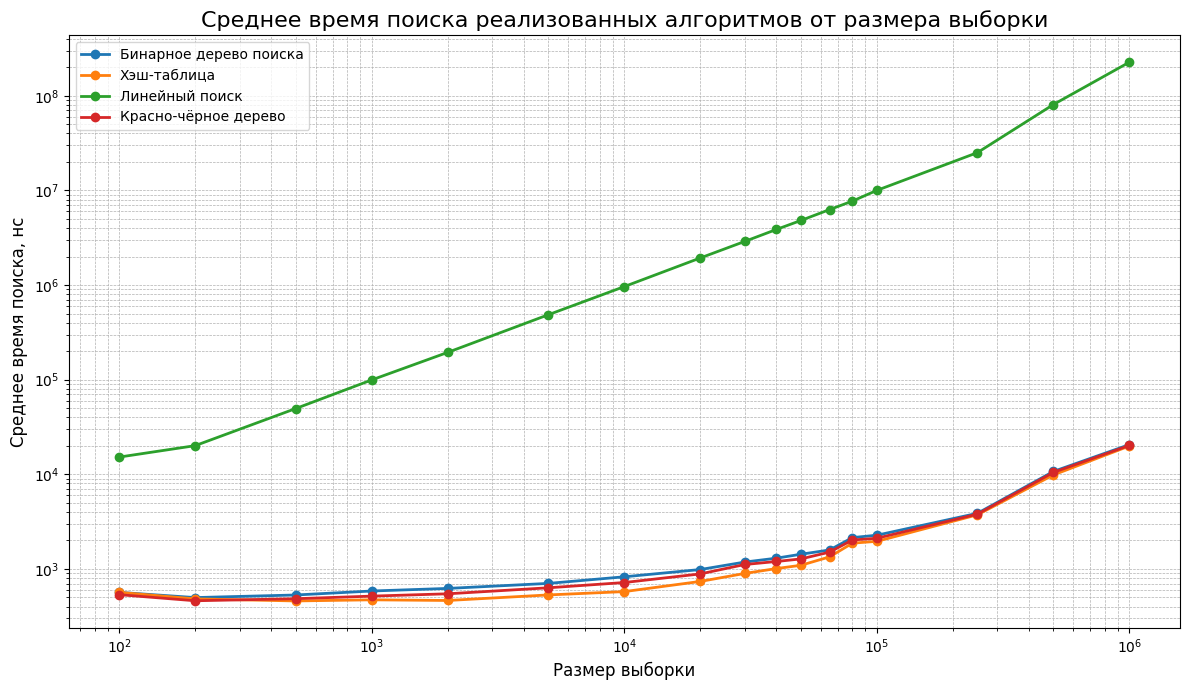

In [5]:
plt.figure(figsize=(12, 7))

only_algs = mean_search_time[mean_search_time["algorithm"] != "multimap"]

for algorithm in only_algs["algorithm"].unique():
    data = only_algs[only_algs["algorithm"] == algorithm]

    plt.plot(
        data["size"],
        data["mean_nanoseconds"],
        marker="o",
        linewidth=2,
        label=algorithm_names.get(algorithm, algorithm)
    )

plt.title("Среднее время поиска реализованных алгоритмов от размера выборки", fontsize=16)
plt.xlabel("Размер выборки", fontsize=12)
plt.ylabel("Среднее время поиска, нс", fontsize=12)

plt.xscale("log")
plt.yscale("log")

plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.legend()
plt.tight_layout()

plt.savefig("search_time_average_my_algorithms.png", dpi=300)
plt.show()

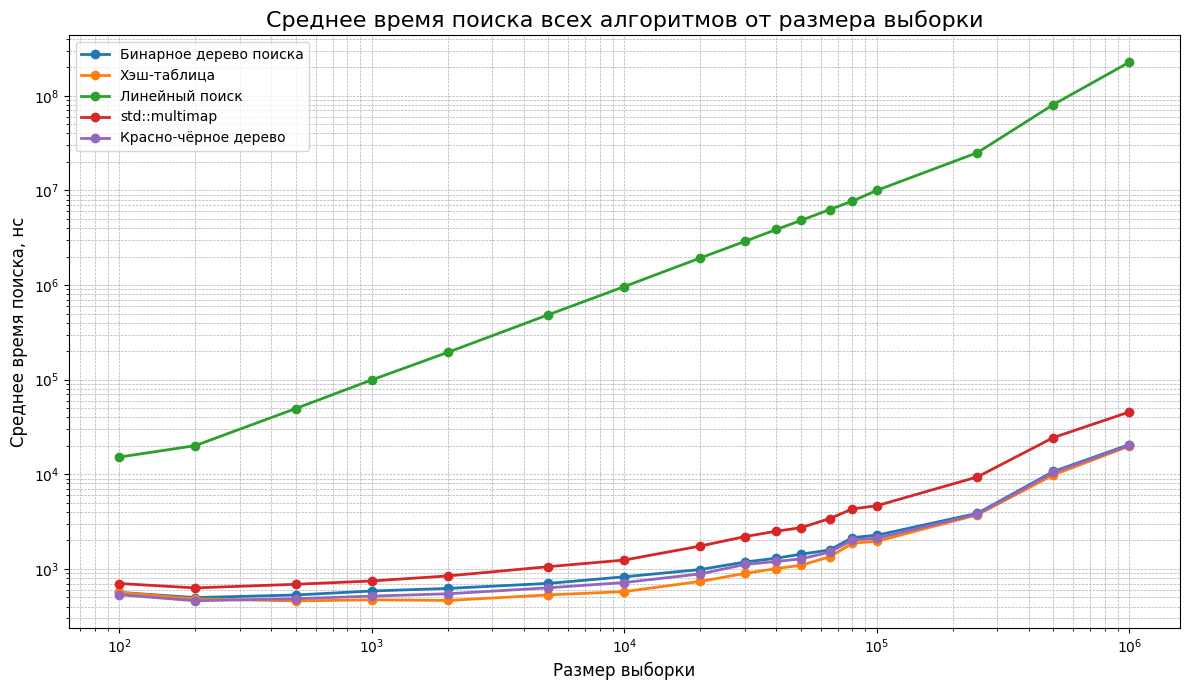

In [23]:
plt.figure(figsize=(12, 7))

for algorithm in mean_search_time["algorithm"].unique():
    data = mean_search_time[mean_search_time["algorithm"] == algorithm]

    plt.plot(
        data["size"],
        data["mean_nanoseconds"],
        marker="o",
        linewidth=2,
        label=algorithm_names.get(algorithm, algorithm)
    )

plt.title("Среднее время поиска всех алгоритмов от размера выборки", fontsize=16)
plt.xlabel("Размер выборки", fontsize=12)
plt.ylabel("Среднее время поиска, нс", fontsize=12)

plt.xscale("log")
plt.yscale("log")

plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.legend()
plt.tight_layout()

plt.savefig("search_time_average_all_algorithms.png", dpi=300)
plt.show()

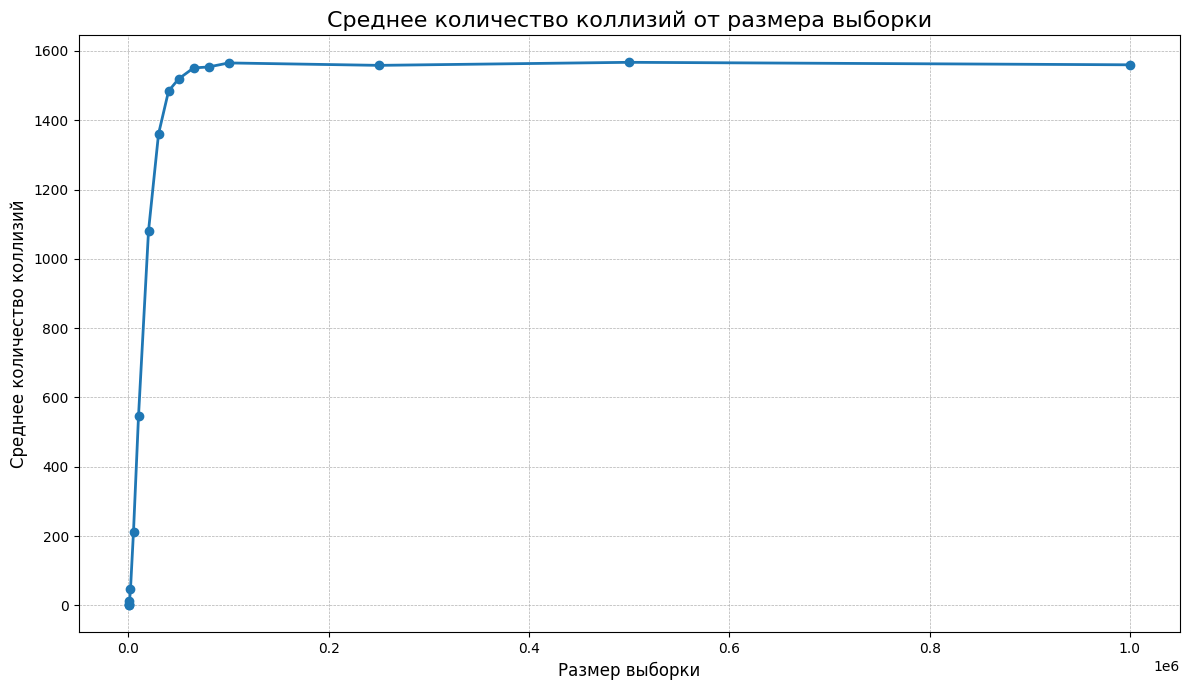

In [15]:
plt.figure(figsize=(12, 7))

plt.plot(
    mean_collision_count["size"],
    mean_collision_count["mean_collisions"],
    marker="o",
    linewidth=2
)

plt.title("Среднее количество коллизий от размера выборки", fontsize=16)
plt.xlabel("Размер выборки", fontsize=12)
plt.ylabel("Среднее количество коллизий", fontsize=12)

plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.tight_layout()

plt.savefig("hash_collisions_average.png", dpi=300)
plt.show()

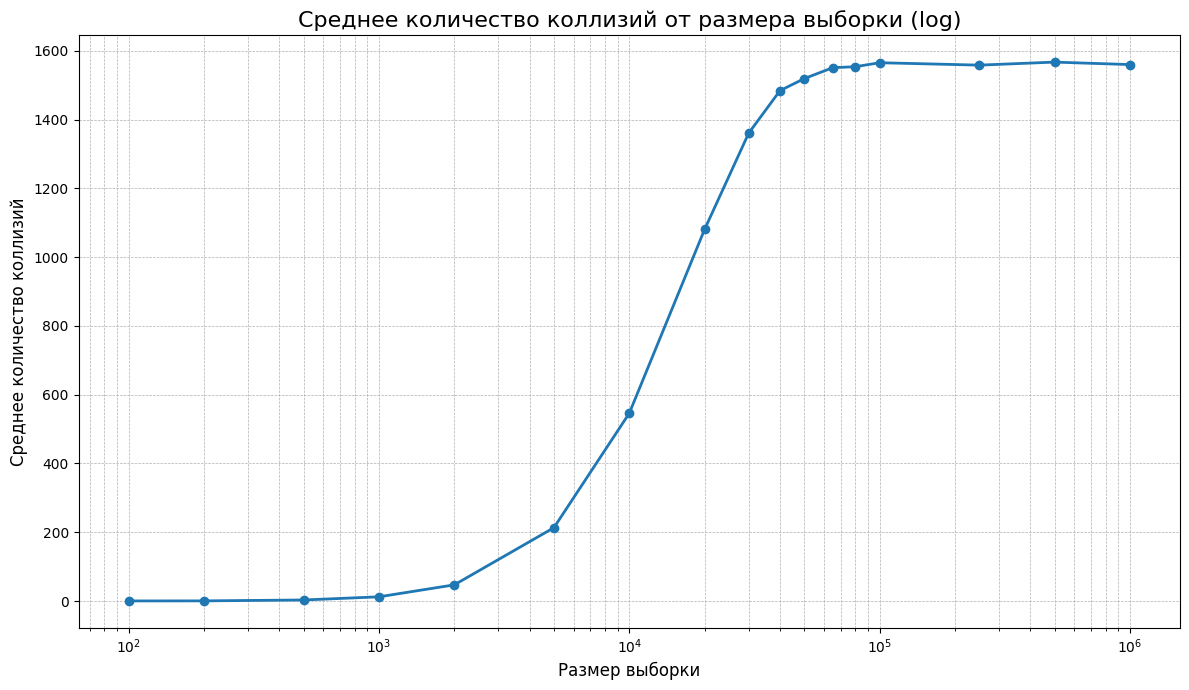

In [25]:
plt.figure(figsize=(12, 7))

plt.plot(
    mean_collision_count["size"],
    mean_collision_count["mean_collisions"],
    marker="o",
    linewidth=2
)

plt.title("Среднее количество коллизий от размера выборки (log)", fontsize=16)
plt.xlabel("Размер выборки", fontsize=12)
plt.ylabel("Среднее количество коллизий", fontsize=12)

plt.xscale("log")

plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.tight_layout()

plt.savefig("hash_collisions_average_log.png", dpi=300)
plt.show()